# Partie B — Comprendre le HMM avant de l'utiliser

Avant de toucher aux données de marché, je vérifie sur des données **simulées** (dont je connais
les vrais régimes et les vrais paramètres) que :
1. mon algorithme forward est correct (B.2) ;
2. `hmmlearn` retrouve les paramètres (B.3) ;
3. je sais gérer le problème des étiquettes qui changent d'une estimation à l'autre (B.4).

**Rappel du modèle.** Un état caché $S_t \in \{0, 1\}$ suit une chaîne de Markov de matrice
$A$ ; conditionnellement à $S_t = k$, le rendement vaut $x_t \sim \mathcal{N}(\mu_k, \sigma_k^2)$.
On n'observe que $x_t$.

In [1]:
import sys
sys.path.insert(0, "..")
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from hmmlearn.hmm import GaussianHMM

from src.forward import simulate_hmm, gaussian_logpdf, forward_filter, forward_unscaled
from src.hmm_model import fit_hmm, sort_states, expected_durations, stationary_distribution
from src.regimes import persistence_table
from src.plotting import set_style, savefig, save_table, CATEGORICAL, SHADE, INK_2, shade_regime

set_style()
pd.set_option("display.precision", 4)

## B.1 — Simulation d'un HMM à 2 états

Paramètres (rendements journaliers **en %**, comme dans le papier) :

| État | $\mu$ | $\sigma$ | proba de rester |
|---|---|---|---|
| 0 = calme | +0,05 % | 0,7 % | 0,98 |
| 1 = crise | −0,10 % | 2,5 % | 0,95 |

Je travaille en % et non en décimal : `hmmlearn` ajoute un plancher `min_covar = 1e-3` aux
variances, qui serait énorme devant une variance de $0{,}007^2 \approx 5\cdot10^{-5}$ en décimal.

In [2]:
PI = np.array([1.0, 0.0])                     # on démarre dans l'état calme
A = np.array([[0.98, 0.02],
              [0.05, 0.95]])
MU = np.array([[0.05], [-0.10]])
SIG = np.array([0.7, 2.5])
COV = (SIG ** 2).reshape(2, 1, 1)
T = 3000

X, states = simulate_hmm(T, PI, A, MU, COV, seed=2024)
idx = pd.RangeIndex(T, name="jour")                    # axe en jours (données simulées)
r = pd.Series(X[:, 0], index=idx, name="rendement (%)")
s = pd.Series(states, index=idx, name="etat_vrai")

print("Durées moyennes théoriques 1/(1-a_kk) :", expected_durations(A), "jours")
print("Loi stationnaire théorique            :", stationary_distribution(A).round(3))
persistence_table(s)

Durées moyennes théoriques 1/(1-a_kk) : [50. 20.] jours
Loi stationnaire théorique            : [0.714 0.286]


,frequence,n_episodes,duree_moyenne_j,duree_mediane_j
etat,,,,
0,0.724,40,54.3000,30.0
1,0.276,39,21.2308,16.0


La loi géométrique donne des séjours moyens de 50 jours (calme) et 20 jours (crise) et une
part de temps en crise de $0{,}02/(0{,}02+0{,}05) \approx 29\,\%$. Les valeurs simulées ci-dessus
en sont proches ; l'écart vient du nombre limité d'épisodes (quelques dizaines seulement en 3 000 jours).

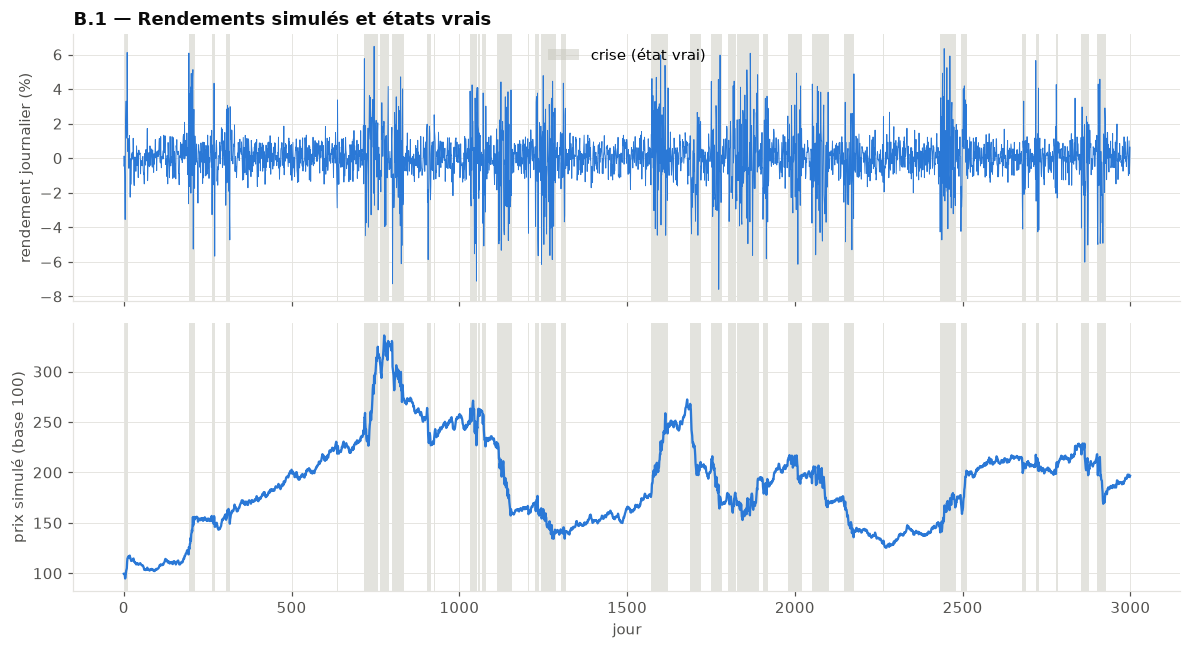

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
shade_regime(axes[0], s, 1, label="crise (état vrai)")
axes[0].plot(r.index, r, color=CATEGORICAL[0], lw=0.6)
axes[0].set_title("B.1 — Rendements simulés et états vrais")
axes[0].set_ylabel("rendement journalier (%)")
axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, 1.0), ncol=1)
shade_regime(axes[1], s, 1)
axes[1].plot(r.index, 100 * (1 + r / 100).cumprod(), color=CATEGORICAL[0])
axes[1].set_ylabel("prix simulé (base 100)")
axes[1].set_xlabel("jour")
fig.tight_layout()
savefig(fig, "B1_simulation")
plt.show()

On voit bien le *volatility clustering* : les périodes grisées (crise) concentrent les grands
mouvements. En revanche la **moyenne** des deux états est presque impossible à distinguer à l'œil :
−0,10 % contre +0,05 % par jour, c'est minuscule devant les écarts-types. Le prix simulé
**monte** même pendant certaines crises (vers le jour 700) : sur 20 jours, une dérive de −2 % pèse peu
face à un écart-type de $2{,}5\,\% \times \sqrt{20} \approx 11\,\%$.

## B.2 — Algorithme forward codé à la main

Le code est dans [`src/forward.py`](../src/forward.py). Récurrence normalisée :

$$\hat\alpha_t(j) = \frac{\left[\sum_i \hat\alpha_{t-1}(i)\,a_{ij}\right] b_j(x_t)}{c_t},
\qquad c_t = \sum_j \left[\sum_i \hat\alpha_{t-1}(i)\,a_{ij}\right] b_j(x_t)$$

On obtient directement la probabilité **filtrée** $\hat\alpha_t(j) = P(S_t = j \mid x_1,\dots,x_t)$
et la log-vraisemblance $\log P(x_{1:T}) = \sum_t \log c_t$.

### Pourquoi normaliser ? Démonstration de l'underflow

In [4]:
log_b = gaussian_logpdf(X, MU, COV)
alpha_brut = forward_unscaled(log_b, PI, A)
somme = alpha_brut.sum(axis=1)
t_zero = int(np.argmax(somme == 0.0))
print(f"Forward non normalisé : sum_j alpha_t(j) = {somme[10]:.3e} en t=10, "
      f"{somme[300]:.3e} en t=300, et exactement 0.0 à partir de t = {t_zero}")

filt, ll = forward_filter(log_b, PI, A)
true_model = GaussianHMM(n_components=2, covariance_type="full")
true_model.n_features = 1
true_model.startprob_, true_model.transmat_, true_model.means_, true_model.covars_ = PI, A, MU, COV
print(f"Log-vraisemblance : mon forward = {ll:.6f} | hmmlearn .score() = {true_model.score(X):.6f}")

Forward non normalisé : sum_j alpha_t(j) = 3.535e-12 en t=10, 2.659e-178 en t=300, et exactement 0.0 à partir de t = 597
Log-vraisemblance : mon forward = -4469.343488 | hmmlearn .score() = -4469.343488


Sans normalisation, $\alpha_t$ est un produit de $t$ densités : il passe sous le plus petit
flottant représentable ($\approx 10^{-308}$) après quelques centaines de jours et devient 0.
Avec la normalisation, la log-vraisemblance est finie et **identique à celle de `hmmlearn`**
à la précision machine (c'est aussi vérifié dans `tests/test_forward.py`).

### Probabilités filtrées vs états vrais (et vs probabilités lissées)

Avec les **vrais** paramètres, je compare trois estimations de l'état :
- la probabilité **filtrée** $P(S_t \mid x_{1:t})$ (mon forward, causale) ;
- la probabilité **lissée** $P(S_t \mid x_{1:T})$ (`predict_proba` de hmmlearn, utilise le futur) ;
- le chemin de **Viterbi** (`predict`, utilise aussi toute la série).

In [5]:
smooth = true_model.predict_proba(X)
viterbi = true_model.predict(X)
p_crise = pd.DataFrame({"filtree": filt[:, 1], "lissee": smooth[:, 1]}, index=idx)

res = pd.DataFrame({
    "précision (% jours bien classés)": [
        np.mean((filt[:, 1] > 0.5) == (states == 1)),
        np.mean((smooth[:, 1] > 0.5) == (states == 1)),
        np.mean(viterbi == states)],
    "rappel crise (% jours de crise détectés)": [
        np.mean(filt[states == 1, 1] > 0.5),
        np.mean(smooth[states == 1, 1] > 0.5),
        np.mean(viterbi[states == 1] == 1)],
}, index=["filtrée (causale)", "lissée (voit le futur)", "Viterbi (voit le futur)"])
save_table(res, "B2_precision_filtre_lisse")
res

,précision (% jours bien classés),rappel crise (% jours de crise détectés)
filtrée (causale),0.9437,0.9094
lissée (voit le futur),0.9723,0.9481
Viterbi (voit le futur),0.9693,0.9312


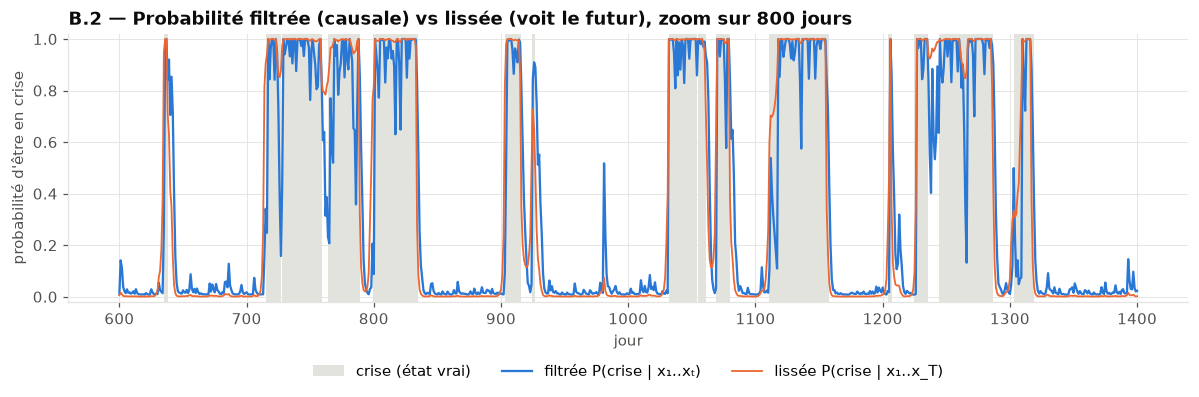

In [6]:
zoom = slice(600, 1400)
fig, ax = plt.subplots(figsize=(11, 3.8))
shade_regime(ax, s.loc[zoom], 1, label="crise (état vrai)")
ax.plot(p_crise.loc[zoom, "filtree"], color=CATEGORICAL[0], label="filtrée P(crise | x₁..xₜ)")
ax.plot(p_crise.loc[zoom, "lissee"], color=CATEGORICAL[1], lw=1.2, label="lissée P(crise | x₁..x_T)")
ax.set_ylim(-0.02, 1.02)
ax.set_ylabel("probabilité d'être en crise")
ax.set_title("B.2 — Probabilité filtrée (causale) vs lissée (voit le futur), zoom sur 800 jours")
ax.set_xlabel("jour")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=3)
fig.tight_layout()
savefig(fig, "B2_filtre_vs_lisse")
plt.show()

**Lecture.** La probabilité filtrée suit bien les états vrais, mais :
- elle **réagit avec un léger retard** à l'entrée en crise : il faut un ou deux grands rendements
  pour « convaincre » le filtre, puisque $a_{00} = 0{,}98$ rend un changement a priori peu probable ;
- elle est plus **bruitée** : un seul grand rendement en période calme la fait monter (pic vers le jour 980),
  et un jour calme en pleine crise la fait redescendre.

La probabilité lissée bascule *pile* au bon moment parce qu'elle sait déjà que les jours suivants
seront agités : c'est de l'information future. Un backtest construit dessus serait faux.
Je mesure ce retard de détection :

In [7]:
entrees = np.where((states[1:] == 1) & (states[:-1] == 0))[0] + 1   # 1er jour de chaque crise
retards = []
for t0 in entrees:
    fin = t0
    while fin < T and states[fin] == 1:
        fin += 1
    detect = np.where(filt[t0:fin, 1] > 0.5)[0]
    retards.append(detect[0] if len(detect) else np.nan)            # nan = crise jamais détectée
retards = pd.Series(retards, name="retard (jours)")
print(f"{len(entrees)} entrées en crise ; retard de détection du filtre (P > 0.5) : "
      f"médiane {retards.median():.0f} j, moyenne {retards.mean():.1f} j, "
      f"{retards.isna().sum()} crise(s) jamais détectée(s)")
retards.describe()

39 entrées en crise ; retard de détection du filtre (P > 0.5) : médiane 1 j, moyenne 1.0 j, 1 crise(s) jamais détectée(s)


count    38.0000
mean      1.0263
std       1.4044
min       0.0000
25%       0.0000
50%       1.0000
75%       1.7500
max       7.0000
Name: retard (jours), dtype: float64

Sur ces données simulées, le retard est **court** (1 jour en médiane, 7 au pire) parce que les deux
régimes sont très différents : σ est multiplié par 3,5 en crise, donc un rendement de ±4 % est
presque une signature de crise. Une crise courte n'a jamais été détectée. Sur les vraies données,
les régimes se chevauchent davantage et le retard sera plus long (je le mesure pour mars 2020 dans le notebook 03).
La précision filtrée (≈ 94 %) reste inférieure à celle des estimations qui voient le futur (≈ 97 %).

## B.3 — Estimation avec `hmmlearn.GaussianHMM`

J'estime maintenant les paramètres sur la série simulée **sans les connaître** (Baum-Welch = EM).

In [8]:
m = GaussianHMM(n_components=2, covariance_type="full", n_iter=1000, tol=1e-4, random_state=0).fit(X)
m_sorted, _ = sort_states(m, by="variance", feature=0)

compar = pd.DataFrame({
    "vrai": [MU[0, 0], SIG[0], A[0, 0], MU[1, 0], SIG[1], A[1, 1]],
    "estimé": [m_sorted.means_[0, 0], np.sqrt(m_sorted.covars_[0, 0, 0]), m_sorted.transmat_[0, 0],
               m_sorted.means_[1, 0], np.sqrt(m_sorted.covars_[1, 0, 0]), m_sorted.transmat_[1, 1]],
}, index=["mu calme (%)", "sigma calme (%)", "a_00", "mu crise (%)", "sigma crise (%)", "a_11"])
# erreur-type approximative d'une moyenne : sigma / sqrt(nombre de jours dans l'état)
n_k = np.bincount(states)
compar["erreur-type approx."] = [SIG[0] / np.sqrt(n_k[0]), np.nan, np.nan,
                                 SIG[1] / np.sqrt(n_k[1]), np.nan, np.nan]
save_table(compar, "B3_parametres_vrais_vs_estimes", ".4f")
compar

,vrai,estimé,erreur-type approx.
mu calme (%),0.05,0.0699,0.0150
sigma calme (%),0.70,0.6907,NaN
a_00,0.98,0.9833,NaN
mu crise (%),-0.10,-0.0582,0.0869
sigma crise (%),2.50,2.5279,NaN
a_11,0.95,0.9581,NaN


Les **volatilités** et les **probabilités de transition** sont très bien retrouvées. Les
**moyennes** le sont beaucoup moins bien en relatif : l'erreur-type d'une moyenne journalière est
de l'ordre de $\sigma/\sqrt{n}$, soit environ 0,015 % pour l'état calme et 0,09 % pour l'état de crise,
du même ordre de grandeur que les moyennes elles-mêmes. Retenir pour la suite : **un HMM identifie des régimes de
volatilité, pas des régimes de rendement.**

### 10 initialisations différentes

In [9]:
rows = []
for seed in range(10):
    mi = GaussianHMM(n_components=2, covariance_type="full", n_iter=1000, tol=1e-4,
                     random_state=seed).fit(X)
    rows.append({"seed": seed, "log-vrais.": mi.score(X), "itérations": mi.monitor_.iter,
                 "mu_0": mi.means_[0, 0], "sigma_0": np.sqrt(mi.covars_[0, 0, 0]),
                 "mu_1": mi.means_[1, 0], "sigma_1": np.sqrt(mi.covars_[1, 0, 0]),
                 "a_00": mi.transmat_[0, 0], "a_11": mi.transmat_[1, 1]})
inits = pd.DataFrame(rows).set_index("seed")
save_table(inits, "B3_dix_initialisations", ".4f")
inits

,log-vrais.,itérations,mu_0,sigma_0,mu_1,sigma_1,a_00,a_11
seed,,,,,,,,
0,-4466.9712,23,-0.0582,2.5279,0.0699,0.6907,0.9581,0.9833
1,-4466.9714,52,-0.0582,2.5279,0.0699,0.6907,0.9581,0.9833
2,-4466.9712,31,-0.0582,2.5279,0.0699,0.6907,0.9581,0.9833
3,-4466.9712,13,0.0699,0.6907,-0.0582,2.5279,0.9833,0.9581
4,-4466.9713,13,0.0699,0.6907,-0.0582,2.5279,0.9833,0.9581
5,-4466.9712,25,0.0699,0.6907,-0.0582,2.5279,0.9833,0.9581
6,-4466.9712,19,-0.0582,2.5279,0.0699,0.6907,0.9581,0.9833
7,-4466.9712,27,0.0699,0.6907,-0.0582,2.5279,0.9833,0.9581
8,-4466.9712,20,0.0699,0.6907,-0.0582,2.5279,0.9833,0.9581


Avec 2 états sur une seule variable, toutes les initialisations atteignent la **même
log-vraisemblance** : l'EM tombe sur le même optimum. Mais **l'ordre des états n'est pas le même** :
selon la graine, l'état 0 est le calme (σ ≈ 0,7) ou la crise (σ ≈ 2,5). C'est le *label switching*
(B.4).

Le problème des optima locaux apparaît dès que le modèle est plus riche. Même expérience avec
**3 états** sur ces mêmes données (le modèle est alors trop riche : il n'y a que 2 vrais états).

In [10]:
rows3 = []
for seed in range(10):
    mi = GaussianHMM(n_components=3, covariance_type="full", n_iter=1000, tol=1e-4,
                     random_state=seed).fit(X)
    sig = np.sort(np.sqrt(mi.covars_[:, 0, 0]))
    rows3.append({"seed": seed, "log-vrais.": mi.score(X), "sigmas triés": np.round(sig, 2),
                  "itérations": mi.monitor_.iter})
inits3 = pd.DataFrame(rows3).set_index("seed")
inits3["écart au meilleur"] = inits3["log-vrais."] - inits3["log-vrais."].max()
inits3

,log-vrais.,sigmas triés,itérations,écart au meilleur
seed,,,,
0,-4461.2471,"[0.34, 0.64, 2.53]",864,-0.0938
1,-4464.3110,"[0.68, 0.69, 2.53]",403,-3.1577
2,-4461.3045,"[0.69, 2.07, 2.12]",1000,-0.1512
3,-4461.1541,"[0.69, 2.01, 2.15]",586,-0.0008
4,-4461.1542,"[0.69, 2.01, 2.15]",589,-0.0009
5,-4461.1550,"[0.69, 1.96, 2.17]",347,-0.0017
6,-4461.1533,"[0.69, 2.01, 2.15]",172,0.0000
7,-4461.1544,"[0.69, 1.96, 2.17]",112,-0.0011
8,-4461.1555,"[0.69, 2.01, 2.15]",1000,-0.0021


Avec 3 états, les solutions ne sont plus identiques : la graine 1 s'arrête 3 points de
log-vraisemblance sous le meilleur (optimum local), et surtout des paramètres **très différents**
donnent presque la même vraisemblance : σ = (0,34 ; 0,64 ; 2,53) pour la graine 0 contre
(0,69 ; 2,01 ; 2,15) pour la graine 6, à 0,09 point d'écart. La vraisemblance est quasi plate :
le 3e état n'est pas identifiable, il découpe arbitrairement un vrai régime en deux.
**Conséquence pratique** : dans la suite du projet, j'estime toujours le HMM avec plusieurs
initialisations (`fit_hmm(..., n_init=...)`) et je garde celle de meilleure vraisemblance.

Au passage, le **BIC** (que j'utiliserai en C.3) retrouve-t-il le bon nombre d'états sur ces données
simulées, où les hypothèses du HMM sont vraies par construction ?

In [11]:
from src.hmm_model import information_criteria
bic_sim = []
for K in range(1, 5):
    mk = fit_hmm(X, K, n_init=5)
    ll_k, aic_k, bic_k = information_criteria(mk, X)
    bic_sim.append({"K": K, "log-vrais.": ll_k, "AIC": aic_k, "BIC": bic_k})
bic_sim = pd.DataFrame(bic_sim).set_index("K")
save_table(bic_sim, "B3_bic_donnees_simulees", ".1f")
bic_sim

,log-vrais.,AIC,BIC
K,,,
1,-5415.5916,10835.1833,10847.1960
2,-4466.9712,8947.9425,8989.9871
3,-4461.1541,8950.3083,9034.3974
4,-4456.6437,8959.2873,9097.4338


Oui : le BIC est minimal pour **K = 2**, le vrai nombre d'états. Passer à 3 états n'améliore la
log-vraisemblance que de quelques points, ce qui ne compense pas la pénalité de 7 paramètres
supplémentaires × ln(3000)/2. C'est une référence utile pour la partie C : si le BIC se comporte
différemment sur les vraies données, ce sera parce que les hypothèses du modèle n'y sont plus vérifiées.

## B.4 — Le label switching et la règle d'identification

graines où l'état 0 = CALME : [3, 4, 5, 7, 8] | graines où l'état 0 = CRISE : [0, 1, 2, 6, 9]


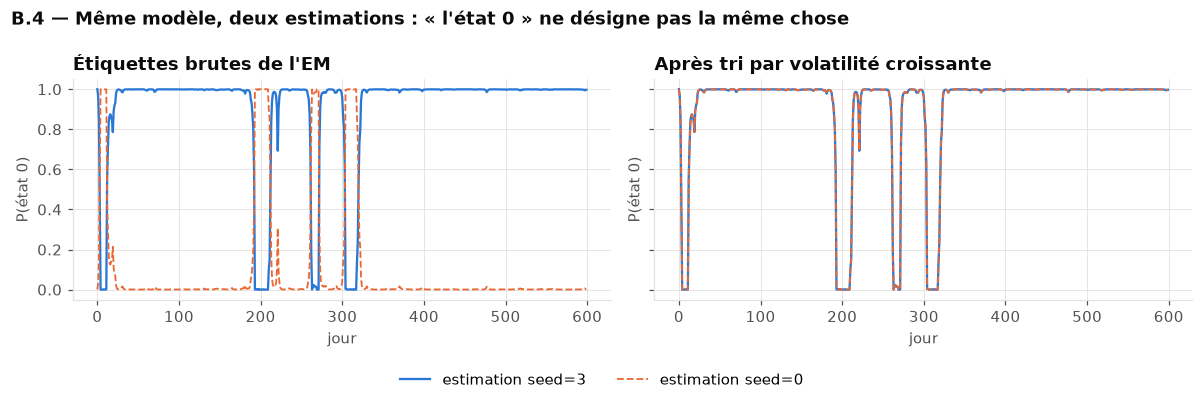

In [12]:
seeds_diff = inits.index[inits["sigma_0"] > 1.5]
seeds_same = inits.index[inits["sigma_0"] < 1.5]
print("graines où l'état 0 = CALME :", list(seeds_same), "| graines où l'état 0 = CRISE :", list(seeds_diff))

sa, sb = seeds_same[0], seeds_diff[0]
ma = GaussianHMM(2, "full", n_iter=1000, tol=1e-4, random_state=sa).fit(X)
mb = GaussianHMM(2, "full", n_iter=1000, tol=1e-4, random_state=sb).fit(X)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for ax, (titre, ma_, mb_) in zip(axes, [("Étiquettes brutes de l'EM", ma, mb),
                                        ("Après tri par volatilité croissante",
                                         sort_states(ma, "variance", 0)[0], sort_states(mb, "variance", 0)[0])]):
    pa, pb = ma_.predict_proba(X)[:, 0], mb_.predict_proba(X)[:, 0]
    ax.plot(idx[:600], pa[:600], color=CATEGORICAL[0], label=f"estimation seed={sa}")
    ax.set_xlabel("jour")
    ax.plot(idx[:600], pb[:600], color=CATEGORICAL[1], lw=1.2, ls="--", label=f"estimation seed={sb}")
    ax.set_title(titre)
    ax.set_ylabel("P(état 0)")
fig.suptitle("B.4 — Même modèle, deux estimations : « l'état 0 » ne désigne pas la même chose",
             x=0.01, ha="left", fontweight="bold", color="#0b0b0b")
fig.tight_layout()
fig.subplots_adjust(bottom=0.25)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2)
savefig(fig, "B4_label_switching")
plt.show()

À gauche, les deux estimations donnent des probabilités **miroir** l'une de l'autre : ce que la
première appelle « état 0 », la seconde l'appelle « état 1 ». Le modèle est le même (même
vraisemblance) : un HMM est invariant par permutation des états, rien dans les données ne dit
lequel doit s'appeler 0.

**Règle d'identification retenue** (fonction `sort_states`) : après chaque estimation, on
renumérote les états par **volatilité croissante** → 0 = le plus calme, K−1 = le plus agité.
À droite, les deux estimations coïncident.

**Pourquoi la volatilité plutôt que le rendement moyen** (le papier nomme ses régimes d'après le
rendement, bull = rendement le plus élevé) ? Parce que la volatilité d'un état est estimée
très précisément alors que son rendement moyen ne l'est pas (voir B.3) : trier par rendement
moyen pourrait inverser deux régimes d'une réestimation à l'autre par simple bruit
d'échantillonnage. Cette règle est essentielle pour le walk-forward (partie D) où le modèle est
réestimé chaque mois : sans elle, la stratégie confondrait « crise » et « calme ».

*Limite de la règle* : si deux états ont des volatilités proches, le tri peut encore permuter
les étiquettes. On pourrait alors apparier les états d'une réestimation à la suivante en
minimisant la distance entre paramètres (algorithme hongrois) ; pour 3 régimes bien séparés en
volatilité, le tri suffit, et je vérifie en partie D que les volatilités moyennes triées restent
stables d'un mois à l'autre.

### Test de la règle sur les 10 initialisations

In [13]:
check = []
for seed in range(10):
    mi = fit_hmm(X, 2, n_init=1, seed=seed)
    mi, perm = sort_states(mi, "variance", 0)
    check.append({"seed": seed, "permutation appliquée": perm.tolist(),
                  "sigma_0 après tri": np.sqrt(mi.covars_[0, 0, 0]),
                  "sigma_1 après tri": np.sqrt(mi.covars_[1, 0, 0])})
pd.DataFrame(check).set_index("seed")

,permutation appliquée,sigma_0 après tri,sigma_1 après tri
seed,,,
0,"[1, 0]",0.6907,2.5279
1,"[1, 0]",0.6907,2.5279
2,"[1, 0]",0.6907,2.5279
3,"[0, 1]",0.6907,2.5279
4,"[0, 1]",0.6907,2.5279
5,"[0, 1]",0.6907,2.5279
6,"[1, 0]",0.6907,2.5279
7,"[0, 1]",0.6907,2.5279
8,"[0, 1]",0.6907,2.5279


Après tri, l'état 0 est toujours le calme (σ ≈ 0,7 %) et l'état 1 toujours la crise (σ ≈ 2,5 %),
quelle que soit la permutation d'origine.

**Bilan de la partie B**
- Mon forward normalisé est correct : même log-vraisemblance que `hmmlearn`, dernière probabilité
  filtrée égale à la dernière probabilité lissée, et aucun underflow (tests unitaires dans `tests/`).
- La probabilité filtrée détecte les crises **avec quelques jours de retard** : c'est le prix à
  payer pour ne pas utiliser le futur.
- L'EM retrouve bien les volatilités et les transitions, mal les moyennes ; il faut plusieurs
  initialisations, et une règle d'identification des états (tri par volatilité).